(lecture2)=
# Input and Output Impedance and Thevenin and Norton Equivalent Circuits

> In this lecture, we will have a closer look at voltage source, current sources, voltage meters, and current meters. We will review the behaviour of ideal sources and meters, and explore the behaviour of "real life" sources and meters, introducing the concept of input and output impedance. We will blur the lines between current and voltage sources, and see that once they are not ideal, all voltage sources can also behave as current sources, and vice versa, depending on the impedance of the load you connect to them. Finally, we will see if you consider connecting to a given node in a complex circuit, the behaviour of the circuit behind that node can always be mapped to an equivalent (non-ideal) voltage source (Thevenin's Theorem), or if you prefer, to an equivalent (non-ideal) current source (Norton's Theorem), allowing you to abstract the full complexity of the circuit behind the node to a single equivalent source and single equivalent output impedance.


<!-- (lo-l1)=
## Learning objectives Lecture 1
And the learning objectives
1. none
2. none
3. none -->

Topics of today:

* Ideal sources
  * Ideal voltage source
  * Ideal current source
* Ideal meters
  * Ideal voltage meter
  * Ideal current meter
* Non-ideal sources and meters
  * Non-ideal voltage source
  * Non-ideal current source
  * Blurring the lines: Equivalence of a voltage source and a current source
  * Measuring the output impedance of non-ideal sources
  * Non-ideal meters
  * Input and output impedance
* Thevenin and Norton's Therems
  * Thevenin's Theorem
  * Norton's Thereom
  * An example of using Thevenin and Nortons's Theorems
* Summary of ideal and non-ideal impedances of sources 


## Ideal Sources

In this section, we will review the properties of ideal sources and meters of voltage and current. 

### The Ideal Voltage source

We will start with the ideal voltage source, shown in the figure below:

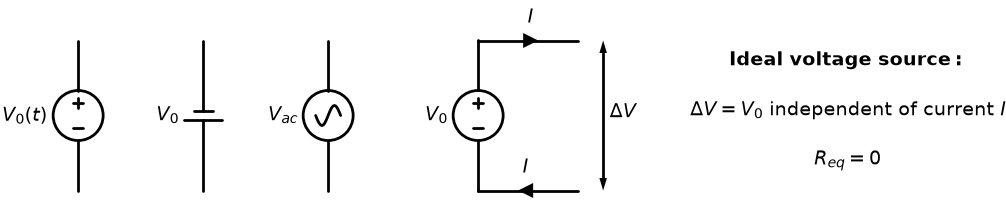

In [638]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # Place a resistor starting at origin (0, 0)
    elm.SourceV().at((0, 0)).up().label("$V_0(t)$")
    elm.BatteryCell().at((2.5,0)).up().label("$V_0$")
    elm.SourceSin().at((5,0)).up().label("$V_{ac}$")
    elm.Line().at((10,0)).left().length(2)
    elm.CurrentLabelInline(direction='in').at((8,0)).label('$I$')
    elm.SourceV().up().label("$V_0$")
    elm.Line().at((8,3)).right().length(2)
    elm.CurrentLabelInline(direction='in').at((10,3)).label('$I$')
    elm.Arrow(double=True).at((10.5,0)).to((10.5,3))
    elm.Label(r"$\Delta V$").at((11,1.5))
    elm.Label(r"$\mathbf{Ideal\ voltage\ source:}$").at((15.5,2.5))
    elm.Label(r"$\Delta V = V_0$ independent of current $I$").at((15.5,1.5))
    elm.Label(r"$R_{eq} = 0$").at((15.5,0.5))


There are many different conventions for notation, but we will follow the following convention. The most general voltage source will consist of a cicle with a minus sign and a plus sign to indicate the polarity of the source. In the most general case, the source will create a voltage drop from it's minus terminal to it's plus terminal given by $V_0(t)$. 

In some cases, this may consist of only a static, time-independent voltage. In electronics, we will refere to this as a "DC" voltage. The letters DC come from the expression [direct current](https://en.wikipedia.org/wiki/Direct_current), used to refer to static currents and voltages. Sometimes, we will use the battery symbol (second from left) to emphasize that this particular voltage source supplies only a static "DC" voltage. DC voltage sources come about quite naturally: in the form of a [battery](https://en.wikipedia.org/wiki/Electric_battery), which uses the electrochemical reactions to provide an (approximately) constant voltage. 

The third type of voltage source you will encounter is the third one from the left, used in electronics to represent an "AC" voltage, where the letters AC come from the expression [alternating current](https://en.wikipedia.org/wiki/Alternating_current), used to refer to purely sinusoidal voltages and currents with no average value. This is also why it is not neccessary to indicated a positive and negative terminal on AC voltage sources. 

An important characteristic of the ideal voltage source is that it will always create the same voltage difference $\Delta V = V_0$ *independenet* of how much current is flowing out of it. Because the voltage remains constant when the current changes, we can see that the equivalent resistance $R_{eq}$ of an ideal voltage source is zero. 

You can now get an idea of why this is an idealisation: if you short circuit the terminals of an ideal voltage source with a zero-ohm resistance, then the ideal source will output an *infinite* amount of current, and also supply an *infinite* amount of power. 

We can visualise the behaviour of an ideal voltage source by looking at a plot of the voltage $V$ it outputs as a function of the current $I$ flowing out of it in an "IV" plot:

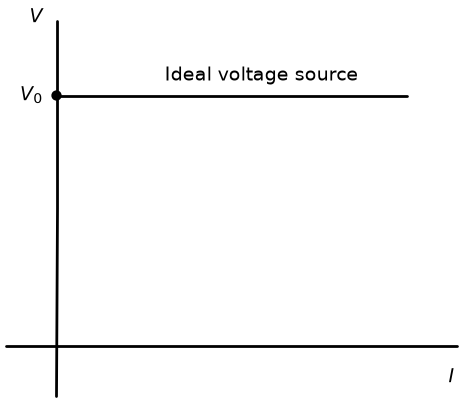

In [642]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((-1,0)).right().length(9)
    elm.Line().at((0,-1)).up().length(7.5)
    elm.Label("$V$").at((-0.3,6.5))
    elm.Label("$I$").at((8,-0.7))
    elm.Line().at((0,5)).right().length(7)
    elm.Dot().at((0,5))
    elm.Label("$V_0$").at((-0.6,4.9))
    elm.Label("Ideal voltage source").at((4,5.3))

In the IV plot, the characteristics of an ideal voltage source are a horizontal line. This is also a way to understand the $R_{eq} = 0$ of the ideal voltage source, since a non-zero resistance would have a sloping line in this plot. 

### The ideal current source

Voltage sources may be something that you are familiar with from previous courses. In addition to voltage sources, it is also possible to make a devices that sources *current*:

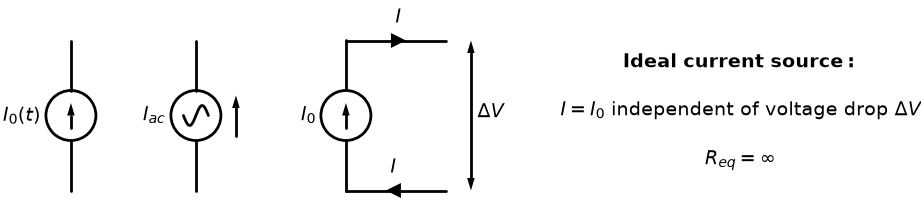

In [640]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # Place a resistor starting at origin (0, 0)
    elm.SourceI().at((2.5,0)).up().label("$I_0(t)$")
    S1 = elm.SourceSin().at((5,0)).up().label("$I_{ac}$")
    elm.Arrow().at((5.8,1.1)).to((5.8,1.9))
    elm.Line().at((10,0)).left().length(2)
    elm.CurrentLabelInline(direction='in').at((8,0)).label('$I$')
    elm.SourceI().up().label("$I_0$")
    elm.Line().at((8,3)).right().length(2)
    elm.CurrentLabelInline(direction='in').at((10,3)).label('$I$')
    elm.Arrow(double=True).at((10.5,0)).to((10.5,3))
    elm.Label(r"$\Delta V$").at((11,1.5))
    elm.Label(r"$\mathbf{Ideal\ current\ source:}$").at((16,2.5))
    elm.Label(r"$I = I_0$ independent of voltage drop $\Delta V$").at((16,1.5))
    elm.Label(r"$R_{eq} = \infty$").at((16,0.5))

We draw this current source device as a circle with an arrow inside of it, indicating the direction of flow of a positive current. There is no separate symbol for a DC current source. We will also sometimes want to indicate a purely AC current source, which we will do using a circle with a sine wave inside of it and then an arrow beside it to emphasize that this is an AC current source, not an AC voltage source. 

An ideal current source will *always* drive the same current $I_0$ from its input to its output *independent* of the voltage drop $\Delta V$ across it. In contrast to the ideal voltage source, the equivalent resistance of an ideal voltage source is infinite: no matter how much you change the voltage across it, the current will never change. 

While voltage sources seem quite intuitive, providing a "driving force" that creates currents in a circuit, current sources are somewhat less natural. It is a bit of a strange device that will adjust voltage it outputs continuously to keep the current constant. This is also how many ideal voltage sources are implemented in general: they are made by including a current meter that measures the current flowing and then feeds back to a voltage source whose voltage is changed with a feedback loop to keep the current constant. As we will see later, there are also other ways that are simpler if you are happy with a not-quite ideal voltage source. 

Like the ideal voltage source, the ideal current source is also clearly no physically possible: an open-circuit ideal current source, for which the terminals are connected by an infinite resistance, would induce try to induce an infinite voltage difference $\Delta V$ to try to get current to flow. 

In an IV plot, the characteristics of an ideal current source is a vertical line:

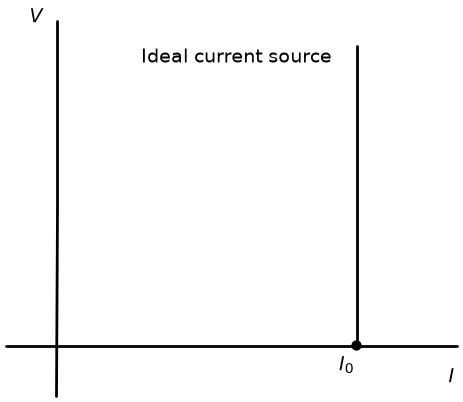

In [645]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((-1,0)).right().length(9)
    elm.Line().at((0,-1)).up().length(7.5)
    elm.Label("$V$").at((-0.3,6.5))
    elm.Label("$I$").at((8,-0.7))
    elm.Line().at((6,0)).up().length(6)
    elm.Dot().at((6,0))
    elm.Label("Ideal current source").at((3.7,5.7))
    elm.Label("$I_0$").at((5.9,-0.5))


The infinite equivalent resistance of the current source can also be seen in the infinite slope of the line in the IV plot. 

## Ideal Meters

Before we move on to real-life (non-ideal) stuff, we will first review the properties of ideal voltage and current meters.

### Ideal Voltage Meters

A voltage meter is a device you can connect *in parallel* across two nodes of your circuit to measure the voltage difference between them, illustrated here:

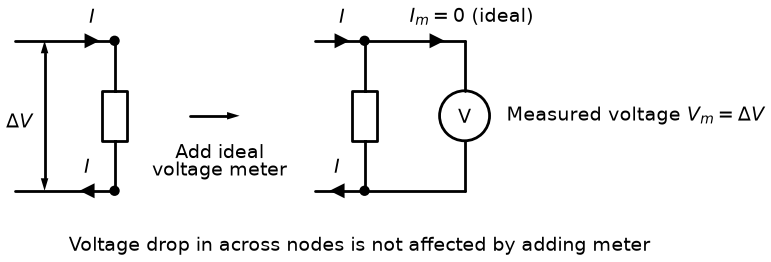

In [650]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().right().length(2).at((0,0))
    elm.Dot()
    elm.CurrentLabelInline(direction='in').at((2.5,0)).label('$I$')
    elm.ResistorIEC().down()
    elm.Dot()
    elm.Line().left().length(2)
    elm.CurrentLabelInline(direction='in').at((0.5,-3)).label('$I$')
    elm.Arrow(double=True).at((0.6,0)).to((0.6,-3))
    elm.Label(r"$\Delta V$").at((0,-1.5))
    
    # transition
    elm.Arrow().right().at((3.5,-1.5)).length(1)
    elm.Label("Add ideal\nvoltage meter").at((4,-2.5))
    
    # with volt meter
    elm.Line().right().length(1).at((6,0))
    elm.Dot()
    elm.CurrentLabelInline(direction='in').at((7.5,0)).label('$I$')
    d.push()
    elm.ResistorIEC().down()
    elm.Dot()
    elm.Line().left().length(1)
    elm.CurrentLabelInline(direction='in').at((5.5,-3)).label('$I$')
    d.pop()
    elm.Line().right().length(2)
    elm.MeterV().down().label(r"Measured voltage $V_m = \Delta V$", ofst=-6.5)
    elm.Line().left().length(2)
    elm.CurrentLabelInline(direction='out').at((7.5,0)).label('$I_m = 0$ (ideal)', ofst=(-0.7,0))
    elm.Label("Voltage drop in across nodes is not affected by adding meter").at((7,-4))

The ideal voltage meter is represented in the circuit diagram as a circle with the letter $V$ inside of it. 

In an ideal voltage meter, no current is allowed to flow into the voltage meter. The current flowing in your circuit is unaffected, and the voltage that your meter measures $V_m$ is equal to the voltage drop $\Delta V$ that existed in your circuit before you attached the voltage meter. 

Since the current flowing into the ideal voltmeter is zero independent of the voltage across it, we can see that the ideal voltmeter has an infinite equivalent resistance: $R_{eq} = \infty$. 

### Ideal current meters

A current meter is a device that is able to measure the current flowing in a branch of your circuit. Unlike the voltage meter, you cannot just add it "in parallel": the curent meter goes *in series* with the branch of the circuit on which you want to measure the current. You need to disconnect one of the branches of your circuit and replace one of the (ideal) wires in your circuit with the current meter: 

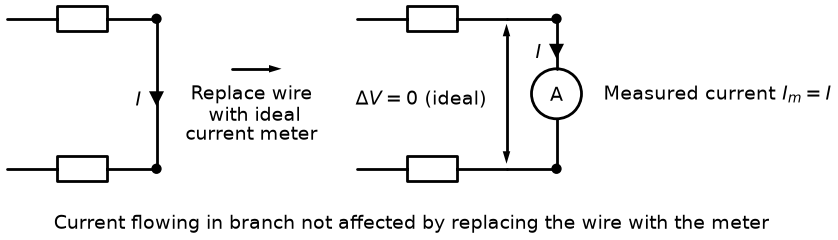

In [649]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.ResistorIEC().right()
    elm.Dot()
    L = elm.Line().down()
    elm.CurrentLabelInline(direction='in', ofst=-0.25).at(L).label('$I$')
    elm.Dot()
    elm.ResistorIEC().left()

    
    # transition
    elm.Arrow().right().at((4.5,-1)).length(1)
    elm.Label("Replace wire\n with ideal\ncurrent meter").at((4.8,-2))

    # with emter
    elm.ResistorIEC().right().at((7,0))
    elm.Line().length(1)
    elm.Dot()
    L = elm.MeterA().down().label(r"Measured current $I_m = I$", ofst=-6)
    elm.CurrentLabelInline(direction='in', ofst=0.7).at(L).label('$I$')
    elm.Dot()
    elm.Line().left().length(1)
    elm.ResistorIEC().left()
    elm.Arrow(double=True).at((10,-0.1)).to((10,-2.9))
    elm.Label(r"$\Delta V = 0$ (ideal)").at((8.2,-1.5))
    elm.Label("Current flowing in branch not affected by replacing the wire with the meter").at((8,-4))

The current meter is represented in the circuit diagram as a circle with the letter "A" in the middle. A current meter also known as an ammmeter, coming from the unit "Amps" of current (hence also the use of the letter A in the circuit diagram). 

In an ideal current meter, there is no voltage drop across the meter, and the current it will measure $I_m$ is equal to the current $I$ that was flowing in the circuit before you connected the current meter. 

While the equivalent (input) resistance of the voltmeter is infinite, from the fact that there is zero voltage independent of the current flowing into it, we can see that the equivalent input resistance of the ideal current meter is $R_{eq} = 0$. 

## Non-ideal sources and meters

### Non-ideal voltage sources

As we saw above, an ideal voltage source cannot really exist in nature as it would have to be able to output an infinite amount of current. 

In practice, for a real voltage source, the voltage it outputs will drop as the current is increased. In a linear circuit, this accounted for by representing a non-ideal voltage source as an ideal voltage source with an "output" resistor $R_o$ in series with its output:

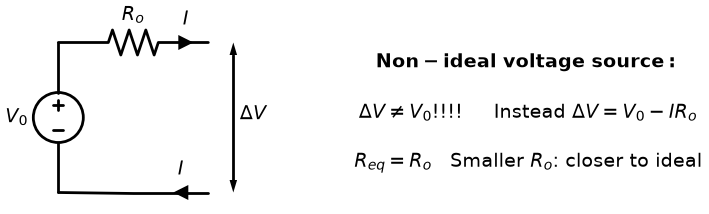

In [651]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((11,0)).left().length(3)
    elm.CurrentLabelInline(direction='in').at((9.5,0)).label('$I$')
    elm.SourceV().up().label("$V_0$")
    elm.Resistor().at((8,3)).right().length(3).label("$R_o$")
    elm.CurrentLabelInline(direction='in').at((11.5,3)).label('$I$')
    elm.Arrow(double=True).at((11.5,0)).to((11.5,3))
    elm.Label(r"$\Delta V$").at((12,1.5))
    elm.Label(r"$\mathbf{Non-ideal\ voltage\ source:}$").at((17.5,2.5))
    elm.Label(r"$\Delta V \neq V_0$!!!!     Instead $\Delta V = V_0 - IR_o$").at((17.5,1.5))
    elm.Label(r"$ R_{eq} = R_o$   Smaller $R_o$: closer to ideal").at((17.5,0.5))


In the non-ideal voltage source, there is now a voltage drop as the current is increased: the voltage $\Delta V$ at the output terminals is given by $\Delta V = V_0 - I R_o$. 

The closer that the output resistance $R_o$ of the voltage source is to zero, the closer the voltage source gets to an ideal voltage source. 

In an IV plot, the characteristic of a non-ideal voltage source is a downwards sloping line:

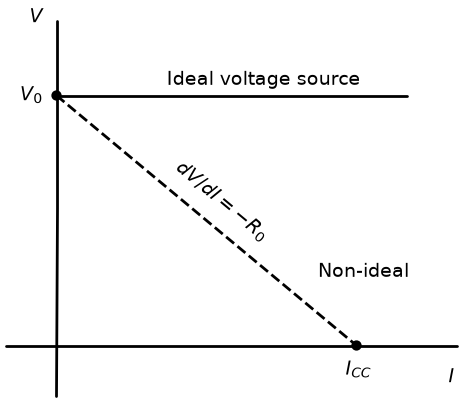

In [653]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((-1,0)).right().length(9)
    elm.Line().at((0,-1)).up().length(7.5)
    elm.Label("$V$").at((-0.3,6.5))
    elm.Label("$I$").at((8,-0.7))
    elm.Line().at((0,5)).right().length(7)
    elm.Dot().at((0,5))
    elm.Label("$V_0$").at((-0.6,4.9))
    elm.Line().endpoints((0,5),(6,0)).linestyle("--").label("$dV/dI = -R_0$",rotate=True, ofst=.3)
    elm.Dot().at((6,0))
    elm.Label("$I_{CC}$").at((5.9,-0.5))
    elm.Label("Ideal voltage source").at((4,5.3))
    elm.Label("Non-ideal").at((6,1.5))

For zero current, the output voltage is given by the voltage $V_0$ supplied by the internal ideal voltage source. As the current increases, for example by decreasing the resistance of the circuit you are attaching the voltage source to, the voltage begins to drop linearly. If we short circuit the output of the current source, the current is no longer infinite, but instead takes on a closed-circuit value $I_{CC} = V_0 / R_o$. 

From the line, you can also see that the equivalent resitance of the voltage source is now given by $R_{eq} = R_0$. Note that the slope of the line is downwards, which is different than we would ususally expect for a resistor in Ohm's law, which would show an upwards sloping line $V = IR$. The reason for this is that we have drawn the current $I$ flowing *out of* the voltage source, whereas for Ohm's law, we draw the current flowing *into* the resistor. 

### Non-ideal Current Sources

For a non-ideal current source, we will add a resistor *in parallel* with the ideal source:

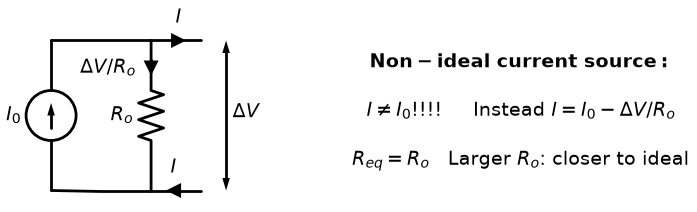

In [655]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((11,0)).left().length(1)
    d.push()
    R1 = elm.Resistor().up().label("$R_o$")
    d.pop()
    elm.Line().left().length(2)
    elm.CurrentLabelInline(direction='in').at((9.5,0)).label('$I$')
    elm.SourceI().up().label("$I_0$")
    elm.Line().right().length(3)
    elm.CurrentLabelInline(direction='in').at((11.5,3)).label('$I$')
    elm.CurrentLabelInline(direction='in', start=False).at(R1).label(r'$\Delta V / R_o$')
    elm.Arrow(double=True).at((11.5,0)).to((11.5,3))
    elm.Label(r"$\Delta V$").at((12,1.5))
    elm.Label(r"$\mathbf{Non-ideal\ current\ source:}$").at((17.5,2.5))
    elm.Label(r"$I \neq I_0$!!!!     Instead $I = I_0 - \Delta V / R_o$").at((17.5,1.5))
    elm.Label(r"$ R_{eq} = R_o$   Larger $R_o$: closer to ideal").at((17.5,0.5))


For the non-ideal current source, as the voltage at the output begins to increase, some of the current $\Delta_o$ being output by the ideal internal current source now flows through the resistor $R_o$ instead of out of the output terminals. 

The characteristic of a non-ideal current source is also a sloping line in the IV plane:

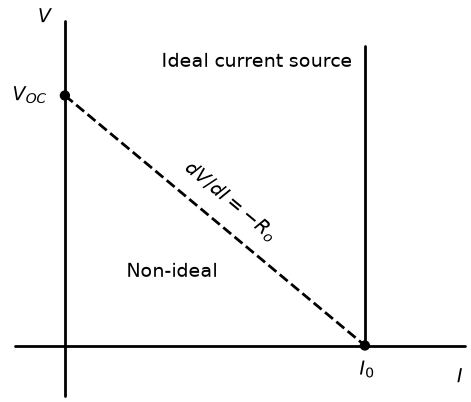

In [657]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((-1,0)).right().length(9)
    elm.Line().at((0,-1)).up().length(7.5)
    elm.Label("$V$").at((-0.3,6.5))
    elm.Label("$I$").at((8,-0.7))
    elm.Line().at((6,0)).up().length(6)
    elm.Dot().at((0,5))
    elm.Label("$V_{OC}$").at((-0.6,4.9))
    elm.Line().endpoints((0,5),(6,0)).linestyle("--").label("$dV/dI = -R_o$",rotate=True, ofst=.3)
    elm.Dot().at((6,0))
    elm.Label("Ideal current source").at((3.7,5.7))
    elm.Label("$I_0$").at((5.9,-0.5))
    elm.Label("Non-ideal").at((2,1.5))

If the output terminals of the non-ideal current source are now left as an open circuit, the voltage difference across the source no longer goes to inifinity but instead reaches a open circuit voltage value of $V_{OC} = I_0 R_o$.  We can also see that the equivalent resistance of the non-ideal current source is also $R_o$.

### Blurring the lines: Equivalence of a voltage source and a current source

Until now, we have been talking about voltage and current sources as different types of devices. However, it can be instructive to look at the IV characteristics of the two side-by-side:

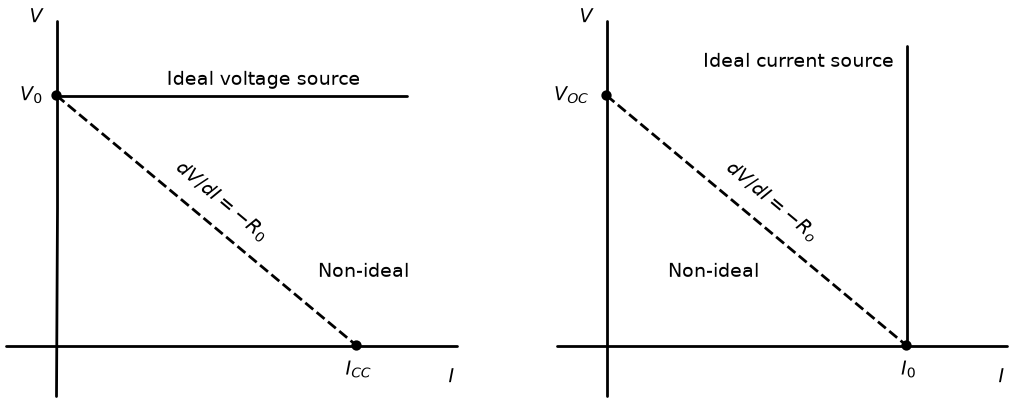

In [668]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((-1,0)).right().length(9)
    elm.Line().at((0,-1)).up().length(7.5)
    elm.Label("$V$").at((-0.3,6.5))
    elm.Label("$I$").at((8,-0.7))
    elm.Line().at((0,5)).right().length(7)
    elm.Dot().at((0,5))
    elm.Label("$V_0$").at((-0.6,4.9))
    elm.Line().endpoints((0,5),(6,0)).linestyle("--").label("$dV/dI = -R_0$",rotate=True, ofst=.3)
    elm.Dot().at((6,0))
    elm.Label("$I_{CC}$").at((5.9,-0.5))
    elm.Label("Ideal voltage source").at((4,5.3))
    elm.Label("Non-ideal").at((6,1.5))

    off = 11
    elm.Line().at((-1+off,0)).right().length(9)
    elm.Line().at((0+off,-1)).up().length(7.5)
    elm.Label("$V$").at((-0.3+off,6.5))
    elm.Label("$I$").at((8+off,-0.7))
    elm.Line().at((6+off,0)).up().length(6)
    elm.Dot().at((0+off,5))
    elm.Label("$V_{OC}$").at((-0.6+off,4.9))
    elm.Line().endpoints((0+off,5),(6+off,0)).linestyle("--").label("$dV/dI = -R_o$",rotate=True, ofst=.3)
    elm.Dot().at((6+off,0))
    elm.Label("Ideal current source").at((3.7+off,5.7))
    elm.Label("$I_0$").at((5.9+off,-0.5))
    elm.Label("Non-ideal").at((2+off,1.5))

In the IV plane, you are not able to distinguish the non-ideal voltage source from the non-ideal current source! This equivalence is not only in the plots, one can show that these two are actually mathematically equivalent:

* A voltage source with voltage $V_0$ and output resistance $R_o$ is equivalent to a current source with current $I_0 = V_0 / R_o$ and output resistance $R_o$
* A current source with current $I_0$ and output resistance $R_o$ is equivalent to a voltage source with voltage $V_0 = I_0 R_o$ and output resistance $R_o$

Note also that the current $I_0$ of the equivalent current source is equal to the closed-circuit current $I_{CC}$ you will measure when you short circuit the output, and the voltage $V_0$ of the equivalent voltage source will be given by the open-circuit voltage $V_{OC}$ you will measure when the output of the circuit is open. 

You can also interchange in a circuit diagram them using these rules whenever it is convenient for you:

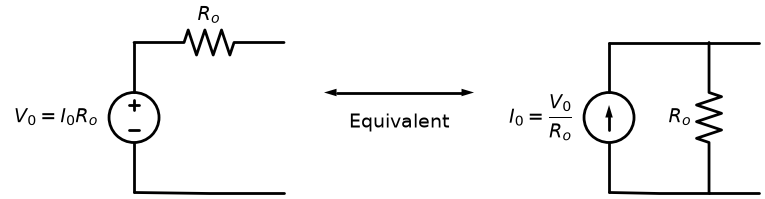

In [671]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().at((0,0)).left().length(3)
    elm.SourceV().up().label("$V_0 = I_0 R_o$ ")
    elm.Resistor().right().length(3).label("$R_o$")

    elm.Line().at((9.5,0)).left().length(1)
    d.push()
    R1 = elm.Resistor().up().label("$R_o$")
    d.pop()
    elm.Line().left().length(2)
    elm.SourceI().up().label(r"$I_0 = \dfrac{V_0}{R_o}$ ")
    elm.Line().right().length(3)
    elm.Arrow(double=True).at((0.8,2)).right()
    elm.Label("Equivalent").at((2.2,1.3))

This equivalence can be very useful in analysing circuits, and will foreshadow the Thevenin and Norton equivalent circuits we will cover at the end of the lecture. 

Another consequence is that any real (non-ideal) voltage source can sometimes behave more like a current source, and vice-versa. How do you know if your source is going to behave more like a voltage source or more like a current source? For this, you need to compare the output impedance of the source to the load impedance $R_L$ of the circuit that you are connecting it to: 

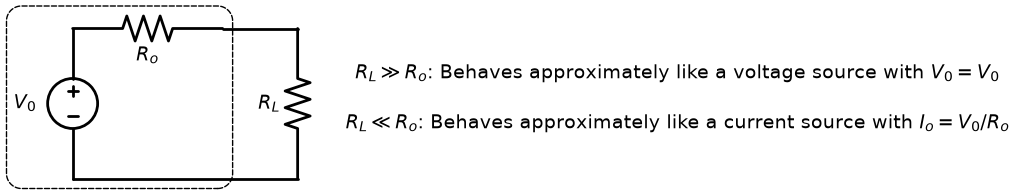

In [677]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    box = []
    elm.Line().at((0,0)).left().length(4.5)
    box.append(elm.SourceV().up().label("$V_0$ "))
    box.append(elm.Resistor().right().length(3).label("$R_o$",loc="bottom"))
    elm.EncircleBox(box).linestyle('--').linewidth(1).color('black')
    elm.Line().right().length(1.5)
    elm.Resistor().down().label("$R_L$")
    elm.Label(r"$R_L \gg R_o$: Behaves approximately like a voltage source with $V_0 = V_0$").at((7.5,2.2))
    elm.Label(r"$R_L \ll R_o$: Behaves approximately like a current source with $I_o = V_0 / R_o$").at((7.5,1.2))

If the output impedance $R_o$ of your source is small compared to the load impedance $R_L$ is large, then your source will behave nearly like an ideal voltage source. 

If the output impedance of your source is large compared to $R_L$, then your source will behave nearly like an ideal current source. 

### Measuring the output impedance of non-ideal sources

Say you have a source in the lab and you want to know what it's output impedance is. How can you do this? 

If you have a current meter and a voltage meter, then you can do this in two simple steps:

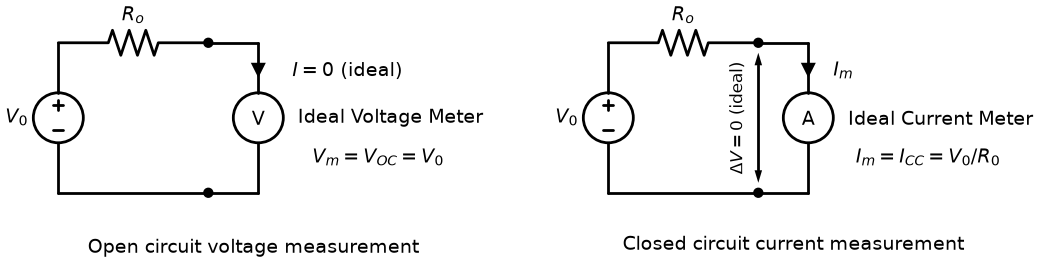

In [672]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up().label("$V_0$")
    elm.Resistor().right().label("$R_o$")
    elm.Dot()
    elm.Line().right().length(1)
    M = elm.MeterV().down().label("Ideal Voltage Meter", ofst=-5)
    elm.CurrentLabelInline(direction='in').at(M).label('$I = 0$ (ideal)', ofst=-3.2)
    elm.Label("$V_m = V_{OC} = V_0$").at((6.3,0.8))
    elm.Line().left().length(1)
    elm.Dot()
    elm.Line().left()
    elm.Label("Open circuit voltage measurement").at((4,-1))

    elm.SourceV().up().label("$V_0$").at((11,0))
    elm.Resistor().right().label("$R_o$")
    elm.Dot()
    elm.Line().right().length(1)
    M2 = elm.MeterA().down().label("Ideal Current Meter", ofst=-5)
    elm.CurrentLabelInline(direction='in').at(M2).label('$I_m$', ofst=-1.2)
    elm.Label("$I_m = I_{CC} = V_0 / R_0$").at((17.3,0.8))
    elm.Line().left().length(1)
    elm.Dot()
    elm.Line().left()
    elm.Arrow(double=True).at((14,0.2)).to((14,2.8)).label(r"$\Delta V = 0$ (ideal)", rotate=True, fontsize=12)
    elm.Label("Closed circuit current measurement").at((14.8,-1.1))


Step 1:

* Connect your source to an (ideal) voltage meter to measure $V_{OC}$
* Connect your source to an (ideal) current meter to measure $I_{CC}$

The equivlent source parameters are:

* Voltage source $V_0 = V_{OC}$
* Current source $I_0 = I_{CC}$
* Output resitance (both) $R_o = V_{OC} / I_{CC}$


### Non-ideal meters

Like voltage sources, voltage and current meters will also never be ideal. To account for the non-ideality of your meters, you will replace them with the following equivalent circuits:

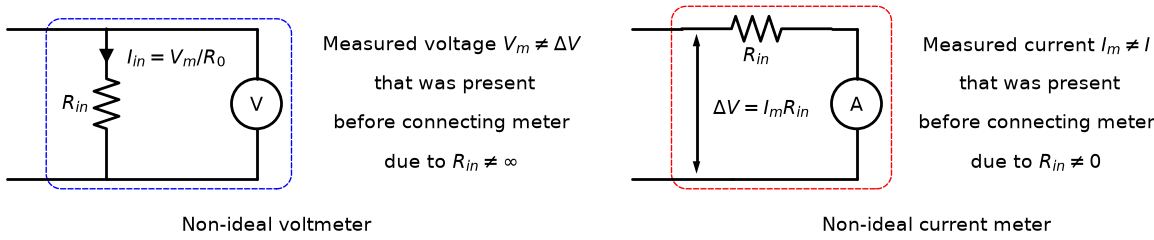

In [674]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Line().right().length(1)
    box = []
    box.append(elm.Line().right().length(1))
    d.push()
    box.append(elm.Resistor().down().label("$R_{in}$"))
    d.pop()
    box.append(elm.Line().right().length(3))
    box.append(elm.MeterV().down())
    box.append(elm.Line().left().length(3))
    elm.Line().left().length(2)
    elm.EncircleBox(box).linestyle('--').linewidth(1).color('blue')
    elm.CurrentLabelInline().down().at((2,-1.5))
    elm.Label(r"Measured voltage $V_m \neq \Delta V$" + 
              "\n\n that was present\n\nbefore connecting meter\n\ndue to" + 
              r" $R_{in} \neq \infty$").at((9,-1.4))
    elm.Label(r"$I_{in} = V_m / R_0$").at((3.5,-0.5))
    elm.Label("Non-ideal voltmeter").at((5.5,-3.8))

    elm.Line().right().length(1).at((12.5,0))
    box = []
    box.append(elm.Resistor().right().label("$R_{in}$", loc="bottom"))
    box.append(elm.Line().right().length(0.5))
    box.append(elm.MeterA().down())
    box.append(elm.Line().left().length(2.5))
    elm.Line().left().length(2)
    elm.EncircleBox(box).linestyle('--').linewidth(1).color('red')
    elm.Arrow(double=True).at((13.8,-0.1)).to((13.8,-2.9))
    elm.Label(r"$\Delta V = I_mR_{in}$").at((15,-1.5))
    elm.Label(r"Measured current $I_m \neq I$" + 
              "\n\n that was present\n\nbefore connecting meter\n\ndue to" + 
              r" $R_{in} \neq 0$").at((20.5,-1.4))
    # elm.CurrentLabelInline().down().at((2,-1.5))
    # elm.Label(r"Measured voltage $V_m \neq \Delta V$" + "\n\n that was present\n\nbefore connecting meter").at((9,-1.4))
    # elm.Label(r"$I_{in} = V_m / R_0$").at((3.5,-0.5))
    elm.Label("Non-ideal current meter").at((18.5,-3.8))



The non-ideal volt meter adds an input resistor $R_{in}$ in parallel with the ideal volt meter (which, as a reminder, has $R_{in} = \infty$). When the measured voltage is not zero, a (hopefully small) current will flow into the meter: if the output impedance of nodes of the circuit that you are connecting to is not zero, then this will cause voltage across the nodes of the circuit you are measuring will be different from the voltage before you connected the meter (you will work out by how much in one of the homework exercises!). 

The non-ideal current meter adds resistor in series with the ideal current meter (reminder, the ideal current meter has $R_{in} = 0$). When the current flowing into the meter is not zero, then a voltage $\Delta V = I_m R_{in}$ will drop across the current meter. Again, depending on the impedance of the circuit you are connecting to, this will result in a different current $I_m$ flowing through the meter than existed in the branch before you connected the meter (also an exercise for your homework).

## Thevenin and Norton Equivalent Theorems

OK, so far, we have spent nearly an entire lecture talking about sources and meters. But surely there is more to circuits than just a simple current or voltage source with a single output resistor? 

While the latter statement is certainly true, if we are interested in the behaviour of a circuit when we connect something (like another circuit) to two of its nodes, we can abstract *all* of the complexity of that circuit into an equivalent single source and single impedance! This idea of putting the full complexity of a circuit into a "black box" is captured in the two theorems we will cover in the next two sections. 

### Thevenin's Theorem

Thevenin's theorem states that I can take any linear circuit, made up of as many linear circuit elements (here resistors, but also later the same will hold if we include capacitors and inductors), and made up as as many voltage sources and currents sources as I want, and if I look at the behaviour of that circuit when I connect to two of it's nodes, I can always rewrite the reponse at the output of these two nodes as a "Thevenin Equivalent Circuit" consisting of an equivalent ideal voltage source in series with an equivalent output resistance (impedance): 

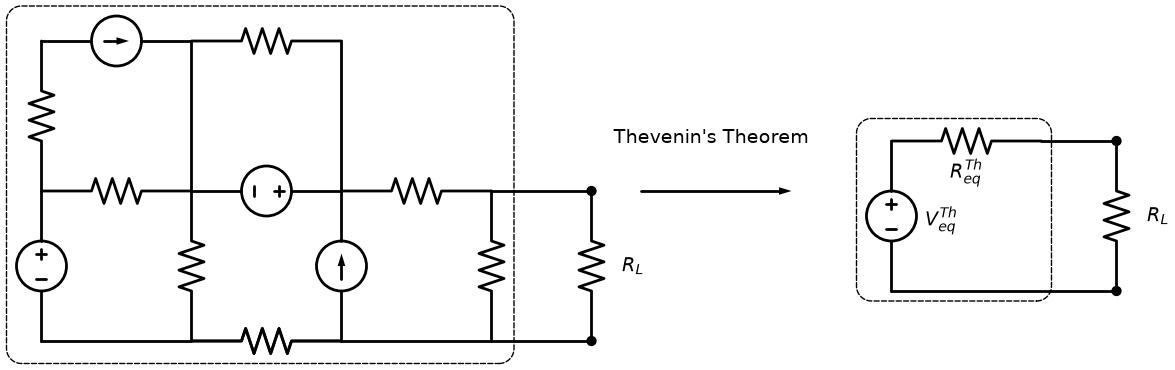

In [679]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up()
    d.push()
    elm.Resistor().right()
    d.pop()
    elm.Resistor().up()
    elm.SourceI().right()
    d.push()
    elm.Resistor().right()
    elm.Line().down()
    d.pop()
    elm.Line().down()
    d.push()
    elm.Resistor().down()
    d.push()
    elm.Line().left()
    d.pop()
    elm.Resistor().right()
    elm.Resistor().left()
    d.pop()
    elm.SourceV().right()
    elm.Resistor().right()
    d.push()
    elm.Resistor().down()
    d.push()
    elm.Line().left()
    elm.SourceI().up()
    d.pop()
    elm.EncircleBox(d.elements).linestyle('--').linewidth(1).color('black')
    elm.Line().right(2)
    elm.Dot()
    d.pop()
    elm.Line().right(2)
    elm.Dot()
    elm.Resistor().down().label("$R_L$",ofst = -1.3)
    elm.Arrow().right().at((12,3))
    elm.Label("Thevenin's Theorem").at((13.3,4))

    #e = elm.SourceV().at((18,1)).label("$V_{eq}^{th}$", ofst=0.2)
    box = []
    e = elm.SourceV().at((17,1))
    box.append(e)
    e = elm.Resistor().right().label("$R_{eq}^{Th}$", loc='bottom', ofst=0.2)
    box.append(e)
    elm.EncircleBox(box).linestyle('--').linewidth(1).color('black')
    elm.Label("$V_{eq}^{Th}$").at((17.9,2.3))
    elm.Line().right().length(1.5)
    elm.Dot()
    elm.Resistor().down().label("$R_L$", ofst=-1.3)
    elm.Dot()
    elm.Line().left().length(4.5)


How do I find the values of $V_{eq}^{th}$ and $R_{eq}^{th}$? We do that using the usual recipe from above:

1. Find (by measuring or by using Kirchoff's laws) the open circuit voltage $V_{OC}$, corresponding to $R_L = \infty$ using an (ideal) volt meter
2. Measure (by measuring or by using Kirchoff's laws) the closed circuit current $I_{CC}$, corresponding to $R_L = 0$ using an (ideal) current meter

We then have: 

$$
V_{eq}^{th} = V_{OC}
$$

and 

$$
R_{eq}^{th} = V_{OC}/I_{CC}
$$

If we want to then predict what current and voltage we will get across a load impedance $R_L$ we attach to the circuit at these node positions, if we know $V_{eq}^{th}$ and $R_{eq}^{th}$, then we can calculate these using the massively simpler equivalent circuit on the left. If we change the loading circuit impedance $R_L$, then we do not need to recalculate everything using Kirchoff's laws: we can just do a single simple re-calculation using the equivalent circuit. When dealing with linear circuits, solving Kirchoff's laws for the two extreme limits ($R_L = 0$ and $R_L = \infty$) allows give us enough information to calculate in one step the resulting behavior for *any* value of $R_L$.  

### Norton's Theorem

The second theorem we will see today is Norton's theorem, which states that if you connect to any two nodes of a circuit, the entire circuit behind those nodes can be represented by a single ideal current source with current $I_{eq}^{N}$ in parallel with an equivalent output impedance $R_{eq}^{N}$: 

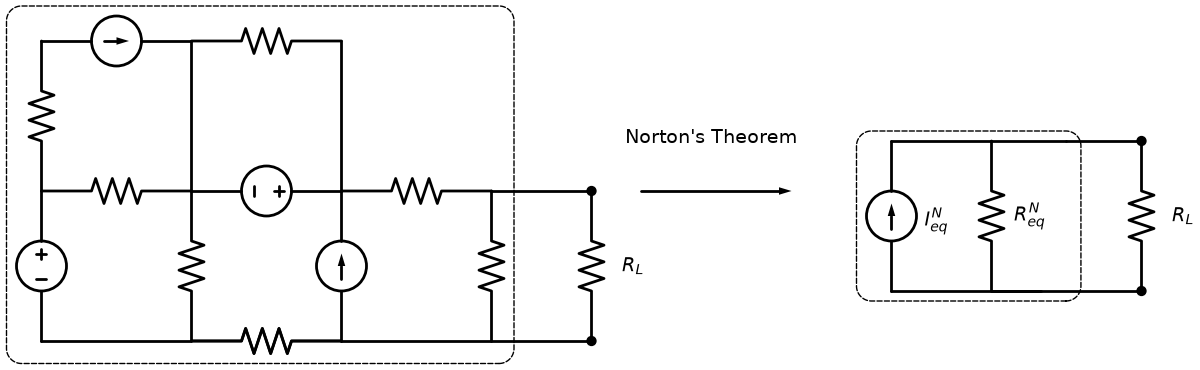

In [576]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up()
    d.push()
    elm.Resistor().right()
    d.pop()
    elm.Resistor().up()
    elm.SourceI().right()
    d.push()
    elm.Resistor().right()
    elm.Line().down()
    d.pop()
    elm.Line().down()
    d.push()
    elm.Resistor().down()
    d.push()
    elm.Line().left()
    d.pop()
    elm.Resistor().right()
    elm.Resistor().left()
    d.pop()
    elm.SourceV().right()
    elm.Resistor().right()
    d.push()
    elm.Resistor().down()
    d.push()
    elm.Line().left()
    elm.SourceI().up()
    d.pop()
    elm.EncircleBox(d.elements).linestyle('--').linewidth(1).color('black')
    elm.Line().right(2)
    elm.Dot()
    d.pop()
    elm.Line().right(2)
    elm.Dot()
    elm.Resistor().down().label("$R_L$",ofst = -1.3)
    elm.Arrow().right().at((12,3))
    elm.Label("Norton's Theorem").at((13.3,4))

    #e = elm.SourceV().at((18,1)).label("$V_{eq}^{th}$", ofst=0.2)
    box = []
    e = elm.SourceI().at((17,1))
    box.append(e)
    e = elm.Line().right().length(2)
    d.push()
    e = elm.Resistor().down().label("$R_{eq}^{N}$", loc='bottom', ofst=0.2)
    box.append(e)
    e = elm.Line().right().length(1)
    d.pop()
    e = elm.Line().right().length(1.5)
    elm.EncircleBox(box).linestyle('--').linewidth(1).color('black')
    elm.Label("$I_{eq}^{N}$").at((17.8,2.3))
    elm.Line().right().length(1.5)
    elm.Dot()
    elm.Resistor().down().label("$R_L$", ofst=-1.3)
    elm.Dot()
    elm.Line().left().length(5)


Given what we already learned above about the equivalence of current and voltage sources, this is perhaps no longer suprising to you :). The procedure for determining the parameters of the Norton equivalent circuit are the same as above (measure open circuit voltage and close circuit current), with then:

$$
I_{eq}^N = I_{CC}
$$

and 

$$
R_{eq}^N = V_{OC} / I_{CC}
$$

Note that the equivalent restance of the two representations is the same $R_{eq}^N = R_{eq}^{Th}$.

### An example of using Thevenin's and Norton's theorems

As an example, we will work out the Thevenin and Norton equivalent representations of a simple circuit.

**Quesiton**: 

Find the Thevenin and Norton equivalent representations of the following circuit as seen across the two illustrated nodes:

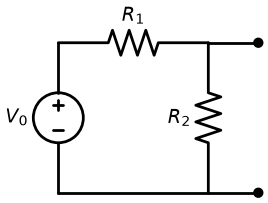

In [680]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up().label("$V_0$")
    elm.Resistor().right().label("$R_1$")
    d.push()
    elm.Line().right().length(1)
    elm.Dot()
    d.pop()
    elm.Resistor().down().label("$R_2$")
    d.push()
    elm.Line().right().length(1)
    elm.Dot()
    d.pop()
    elm.Line().left()
    # elm.Dot().at((6,3))
    # elm.Line().right().length(1)
    # elm.Resistor().down().label("$R_L$",ofst=-1.2)
    # elm.Line().left().length(1)
    # elm.Dot()

**Answer**:

The Thevenin equivalent circuit is a voltage source with voltage $V_{eq}^{Th}$ in series with a resistance $R_{eq}^{Th}$, and the Norton equivalent circuit is a current source with current $I_N$ in parallel 

The first step is to connect an (ideal) voltage meter across the nodes and calculate the open circuit voltage:

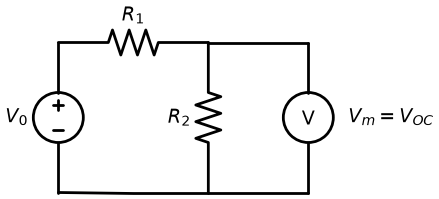

In [636]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up().label("$V_0$")
    elm.Resistor().right().label("$R_1$")
    d.push()
    elm.Resistor().down().label("$R_2$")
    elm.Line().left()
    d.pop()
    elm.Line().right().length(2)
    elm.MeterV().down().label("$V_m = V_{OC}$",ofst=-3)
    elm.Line().left().length(2)

Since no current flows into the ideal voltmeter, the voltage source will drive a current $I$ through the series sum of resistors $R_1$ and $R_2$, with $I$ given by:

$$
I = \frac{V_0}{R_1 + R_2}
$$

The open circuit voltage will then be given by the voltage generated across $R_2$ in response to this current:

$$
V_{OC} = IR_2 = V_0 \frac{R_2}{R_1 + R_2}
$$

You may also recognise this as the output voltage of resisitive voltage divider circuit.

The second step is to calculate the closed circuit current:

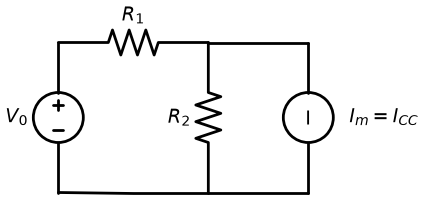

In [609]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up().label("$V_0$")
    elm.Resistor().right().label("$R_1$")
    d.push()
    elm.Resistor().down().label("$R_2$")
    elm.Line().left()
    d.pop()
    elm.Line().right().length(2)
    elm.MeterI().down().label("$I_m = I_{CC}$",ofst=-2.7)
    elm.Line().left().length(2)

In this case, the second resistor is short circuited by the zero resistance of the ideal voltage meter, and all current flows through the meter. This then gives us:

$$
I_{CC} = \frac{V_0}{R_1}
$$

We now have all we need to calculate the parameters of the Thevenin and Norton equivalent circuits:

$$
V_{eq}^{Th} = V_{OC} = \frac{V_0 R_2}{R_1 + R_2}
$$

$$
I_{eq}^N = I_{CC} = \frac{V_0}{R_1}
$$

$$
R_{eq}^{Th} = R_{eq}^N = \frac{V_{OC}}{I_{CC}} = \frac{R_1 R_2}{R_1 + R_2}
$$

You may also recognise the formula of the equivalent resistance: it is the formula you get if you consider the resistance $R_1 || R_2$ of the parallel combination of resistors $R_1$ and $R_2$. 

**But wait a minute:** Aren't $R_1$ and $R_2$ in series in the circuit? Why are we getting an answer that makes them look like they are in parallel? 

The answer is that while the resistors are in series from the point of view of the voltage source $V_0$, that is not the case looking *into* the circuit from the perspective of the two nodes we are connecting to:

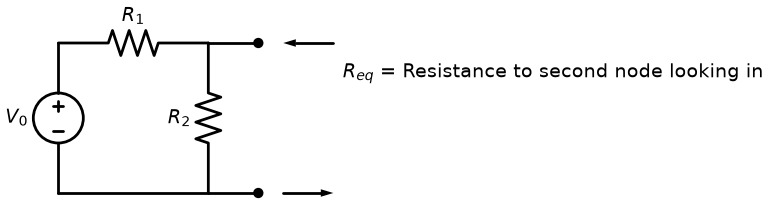

In [633]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.SourceV().up().label("$V_0$")
    elm.Resistor().right().label("$R_1$")
    d.push()
    elm.Line().right().length(1)
    e = elm.Dot()
    d.pop()
    elm.Resistor().down().label("$R_2$")
    d.push()
    elm.Line().right().length(1)
    elm.Dot()
    d.pop()
    elm.Line().left()
    elm.Arrow().left().at((5.5,3)).length(1)
    elm.Label("$R_{eq}$ = Resistance to second node looking in").at((10,2.5))
    elm.Arrow().right().at((4.5,0)).length(1)


As we leaned above, the equivalent resistance of an ideal voltage source is zero. If you take this into account, if you look at the resistance of the circuit looking in from the upper node and coming out of the lower node, then the resistors $R_1$ and $R_2$ from this perspective are in parallel. 

This is another way to find the equivalent resistance of a circuit from a perspective of two nodes:

* Replace all the voltage sources with a short circuit
* Replace all the current sources with an open circuit
* Calculate the resulting resistance from one node to the other

## Summary of ideal and non-ideal impedances of sources and meters

**Sources** connected to circuit with input impedance $R_L$:

* Voltage Source:
  * Ideal output impedance: $R_o = 0$
  * Non-ideal: $R_o \ll R_L$
* Current Source:
  * Ideal output impedance: $R_o = \infty$
  * Non-ideal: $R_o \gg R_L$

**Meters** connected to circuits with output impedance $R_o$:

* Voltage Meter:
  * Ideal input impedance: $R_{in} = \infty$
  * Non-ideal: $R_{in} \gg R_o$
* Current meter:
  * Ideal input impedance: $R_{in} = 0$
  * Non-ideal: $R_{in} \ll R_o$

Some **real-life** values that you will encounter in the lab: 

* Your oscilloscope:
  * Input resistance $R_{in} = 1$ MOhm
  * Note: input also has an capacitance to ground of around 30 pF (see next lectures for the impedance of a capacitor, relevant for non-DC measurements)
* The 5.5 digit DMM:
  * $R_{in} > 100$ MOhm (check manual for exact values)
* The arbitrary waveform generators
  * $R_{out} = 50$ Ohms